In [1]:
from typing import Dict, Sequence

import torch
from _disk_shape import (
    fov_tensor_dict,
    hot_rods_sector_centers,
    single_disk,
    hot_rods_add_sector,
)
from _geometry_2d_transform import transform_to_positions_2d_batch
from matplotlib import pyplot as plt
from torch import Tensor, arange, bucketize, cat
from torch import float32 as torch_float32
from torch import meshgrid, norm, ones, sqrt, stack, tensor, zeros
from torch.nn.functional import conv2d

In [9]:
fov_size_in_mm = (64, 64)  # mm
fov_px_size_in_mm = (0.125, 0.125)  # mm
fov_n_pxs = (
    (torch.tensor(fov_size_in_mm) / torch.tensor(fov_px_size_in_mm))
    .int()
    .tolist()
)

radius = 0.5  # mm
radius_mm_to_px = int(1.0 / fov_px_size_in_mm[0])  # pixels per mm
n_x_layers = 12  # Number of layers in the x-direction
radius_px = int(radius_mm_to_px * radius)  # pixels

fov_dict = fov_tensor_dict(fov_n_pxs, fov_size_in_mm)
for key, value in fov_dict.items():
    if isinstance(value, Tensor):
        fov_dict[key] = value.to(torch_float32)
        print(f"{f'[{key}]':36s}:{fov_dict[key].tolist()}")


[n pixels]                          :[512.0, 512.0]
[size in mm]                        :[64.0, 64.0]
[center coordinates in mm]          :[0.0, 0.0]
[mm per pixel]                      :[0.125, 0.125]
[n subdivisions]                    :[1.0, 1.0]


In [3]:
phantom = torch.zeros(fov_n_pxs, dtype=torch.float32)
pxs_per_mm = int(1.0 / fov_dict["mm per pixel"][0])
radius_px = int(radius * pxs_per_mm)


radii = torch.tensor([0.5, 0.625, 0.75, 1.0, 1.25, 1.5])  # mm
shifts = torch.tensor(
    [[4, 0.0], [4.5, 0.0], [4, 0.0], [5, 0.0], [5, 0.0], [6, 0.0]]
)  # x, y shift in mm
n_x_layers = torch.tensor([14, 11, 9, 7, 6, 5])  # Number of layers in the x-direction

angles = arange(0, 2 * 3.14159, 2 * 3.14159 / 6).unsqueeze(-1) + 3.14159 / 6
# angles = arange(0, 2 * 3.14159, 2 * 3.14159 / 6).unsqueeze(-1)
# shifts = torch.zeros_like(angles).view(-1, 1).repeat(1, 2)

sectors_centers_mm = []
for i in range(shifts.shape[0]):
    transform = cat((angles[i : i + 1], shifts[i : i + 1]), dim=1)
    sector_centers_mm, sector_centers_px = hot_rods_add_sector(
        phantom, int(n_x_layers[i].item()), radii[i].item(), transform, fov_dict
    )
    sectors_centers_mm.append(sector_centers_mm)

# print(f"sector_centers_mm: {sector_centers_mm.shape}")
# print(f"sector_centers_px: {sector_centers_px.shape}")

Sector centers pixels: torch.Size([105, 2])
Sector centers pixels: torch.Size([66, 2])
Sector centers pixels: torch.Size([45, 2])
Sector centers pixels: torch.Size([28, 2])
Sector centers pixels: torch.Size([21, 2])
Sector centers pixels: torch.Size([15, 2])


/home/fanghan/Work/spebt/notes/spebt-research-notes/digital_phantom_generation/develop/_disk_shape.py:77: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  sector_centers_px = bucketize(sector_centers_mm, boundaries)


anno_xy: torch.Size([6, 2])


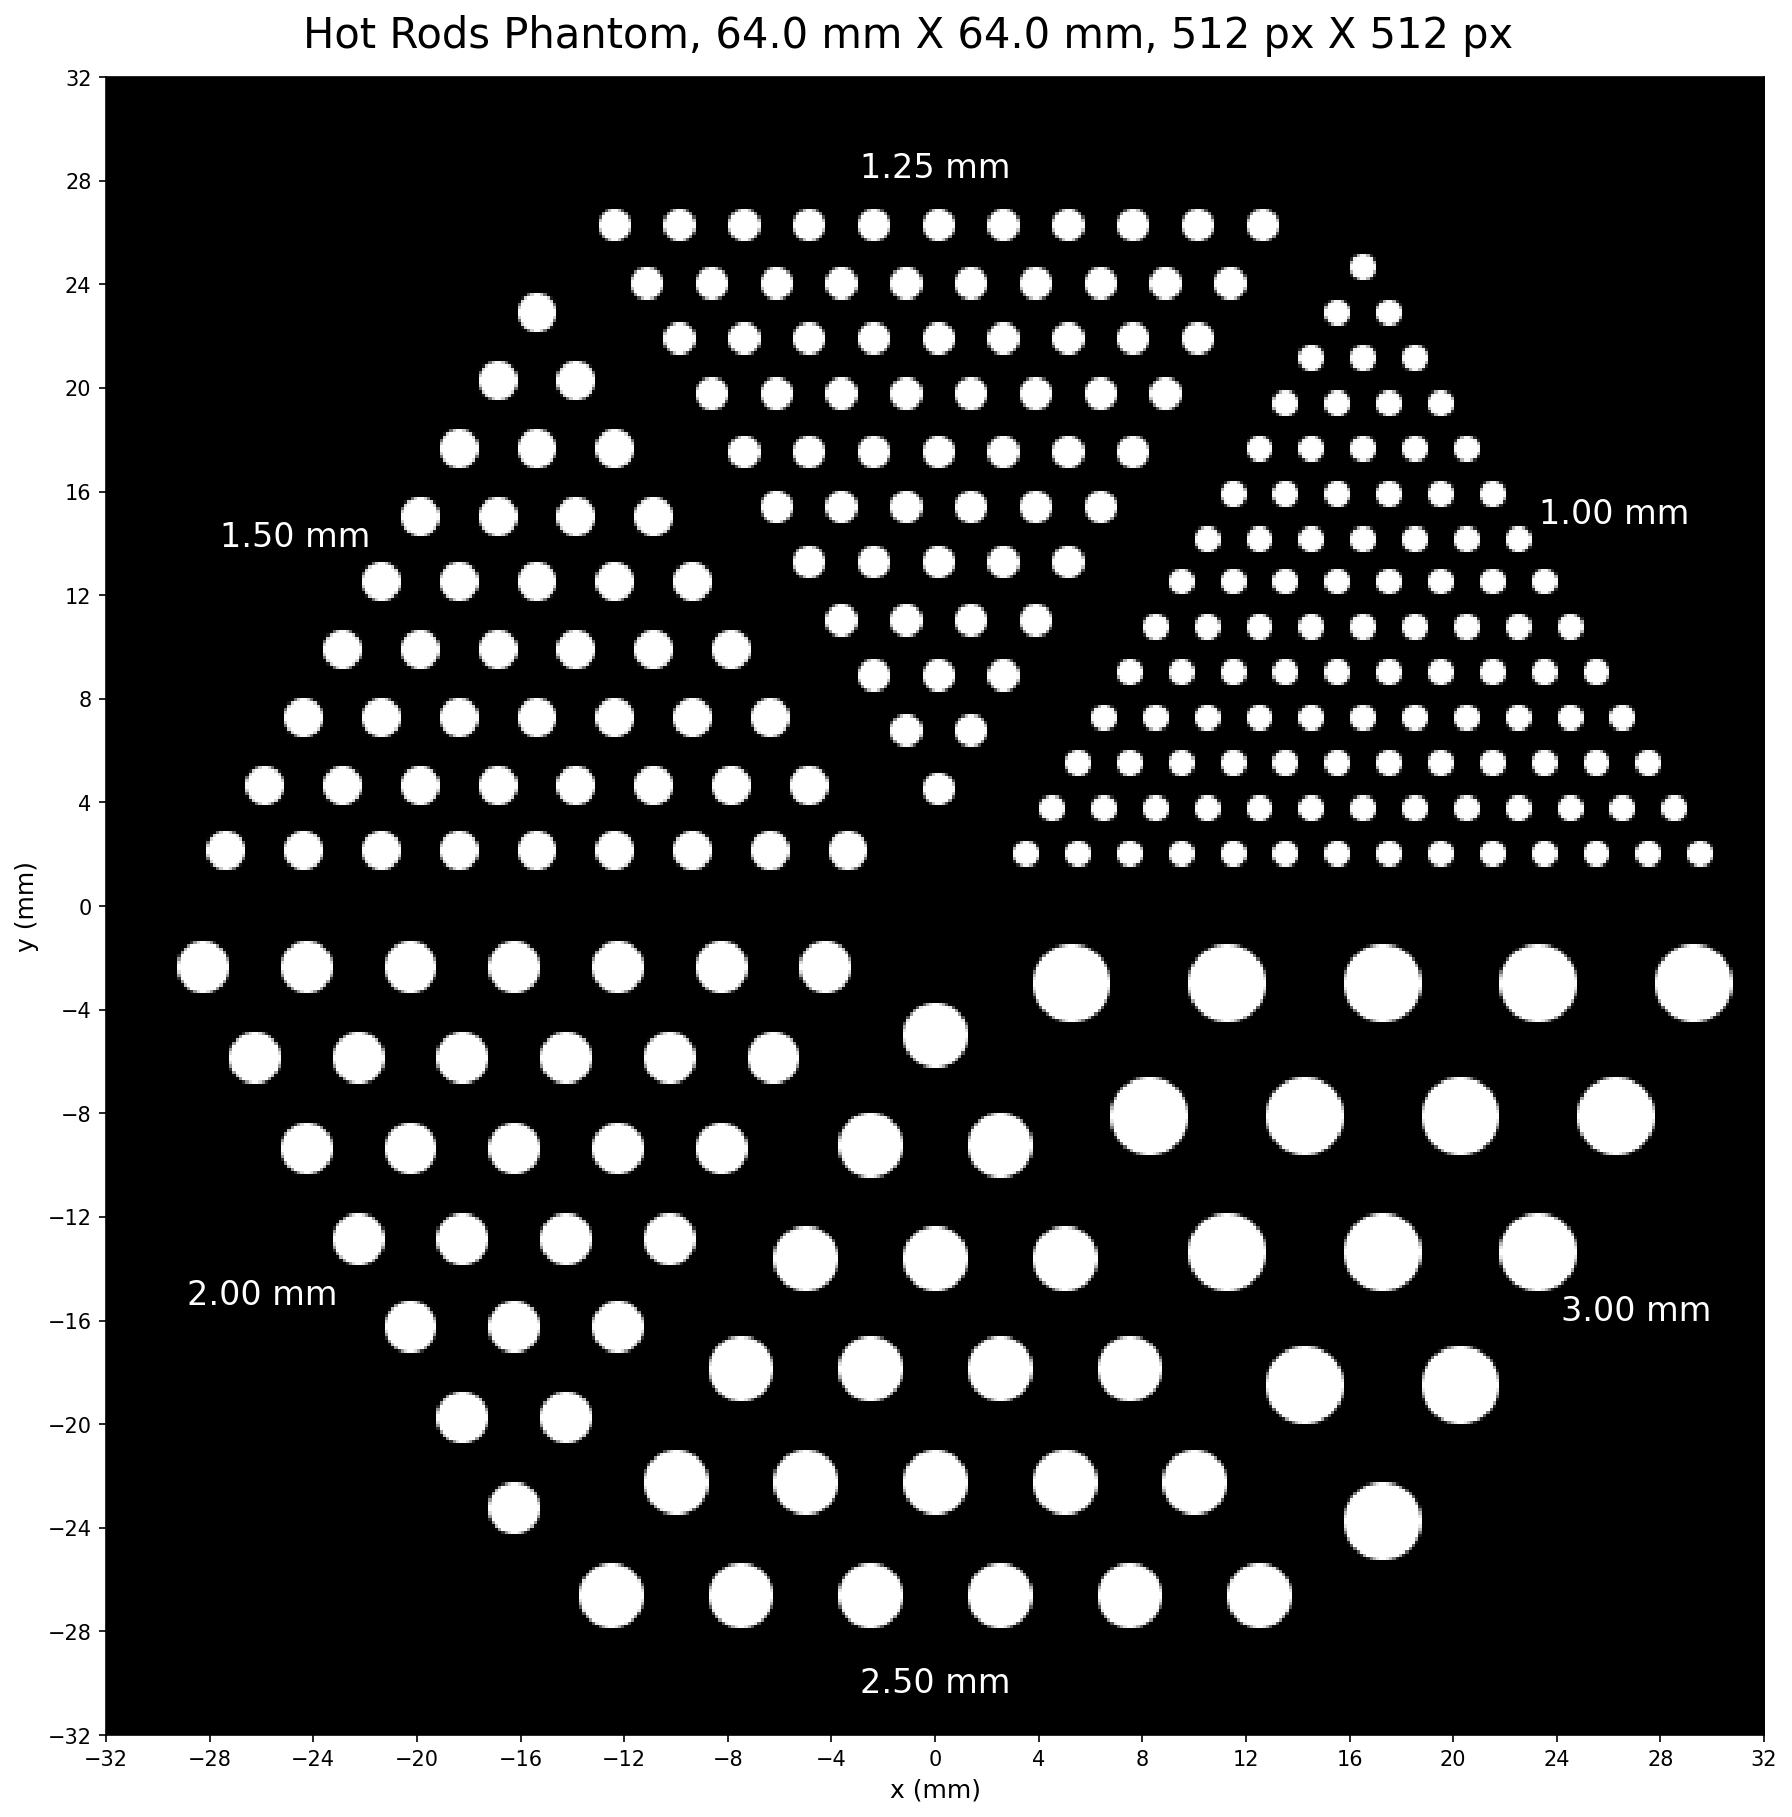

In [18]:
# Plot the phantom with the sector centers

from torch import cos, sin

anno_radii = tensor([30.25, 28.5, 28.5, 30, 30, 31.25])  # mm

anno_xy = cat(
    (cos(angles) * anno_radii.view(-1, 1), sin(angles) * anno_radii.view(-1, 1)), -1
)
anno_text = [f"{r*2:.2f} mm" for r in radii]
print(f"anno_xy: {anno_xy.shape}")


# Use cmap_half_hot for the image
plt.close("all")
fig, ax = plt.subplots(dpi=150, figsize=(12, 12), layout="constrained")
ax.imshow(
    phantom.T,
    cmap="gray",
    extent=(
        -fov_size_in_mm[0] / 2,
        fov_size_in_mm[0] / 2,
        -fov_size_in_mm[1] / 2,
        fov_size_in_mm[1] / 2,
    ),
    origin="lower",
    aspect="equal",
    interpolation="none",
)
# for sector_centers_mm in sectors_centers_mm:
#     ax.plot(
#         sector_centers_mm[:, 0],
#         sector_centers_mm[:, 1],
#         "o",
#         markersize=2,
#     )
xticks = ax.set_xticks(
    arange(-fov_size_in_mm[0] / 2, fov_size_in_mm[0] / 2 + 1, 4),
    # labels=arange(-fov_size_in_mm[0] / 2, fov_size_in_mm[0] / 2 + 1, 4).tolist(),
)
yticks = ax.set_yticks(
    arange(-fov_size_in_mm[0] / 2, fov_size_in_mm[0] / 2 + 1, 4),
    # labels=arange(-fov_size_in_mm[0] / 2, fov_size_in_mm[0] / 2 + 1, 4).tolist(),
)
ax.set_xlabel("x (mm)", fontsize=12)

ax.set_ylabel("y (mm)", fontsize=12)


for i, rad in enumerate(angles):
    ax.annotate(
        anno_text[i],
        xy=(0, 0),
        xytext=tuple(anno_xy[i].tolist()),
        textcoords="data",
        fontsize=16,
        ha="center",
        va="center",
        color="w",
    )
fig_title = f"Hot Rods Phantom, {fov_dict["size in mm"][0].item()} mm X {fov_dict["size in mm"][1].item()} mm"
fig_title += f", {int(fov_dict["n pixels"][0].item())} px X {int(fov_dict["n pixels"][1].item())} px"
fig.suptitle(fig_title, fontsize=20)
fig.savefig(
    f"hot_rods_phantom_{fov_dict["size in mm"][0].item()}_mm_x_{fov_dict["size in mm"][1].item()}_mm.png",
    dpi=150,
)